/tmp/ipykernel_3470388/3174050535.py:50: RuntimeWarning: invalid value encountered in divide
  err_tau = np.abs(tau_app - tau_exact) / np.abs(tau_exact)


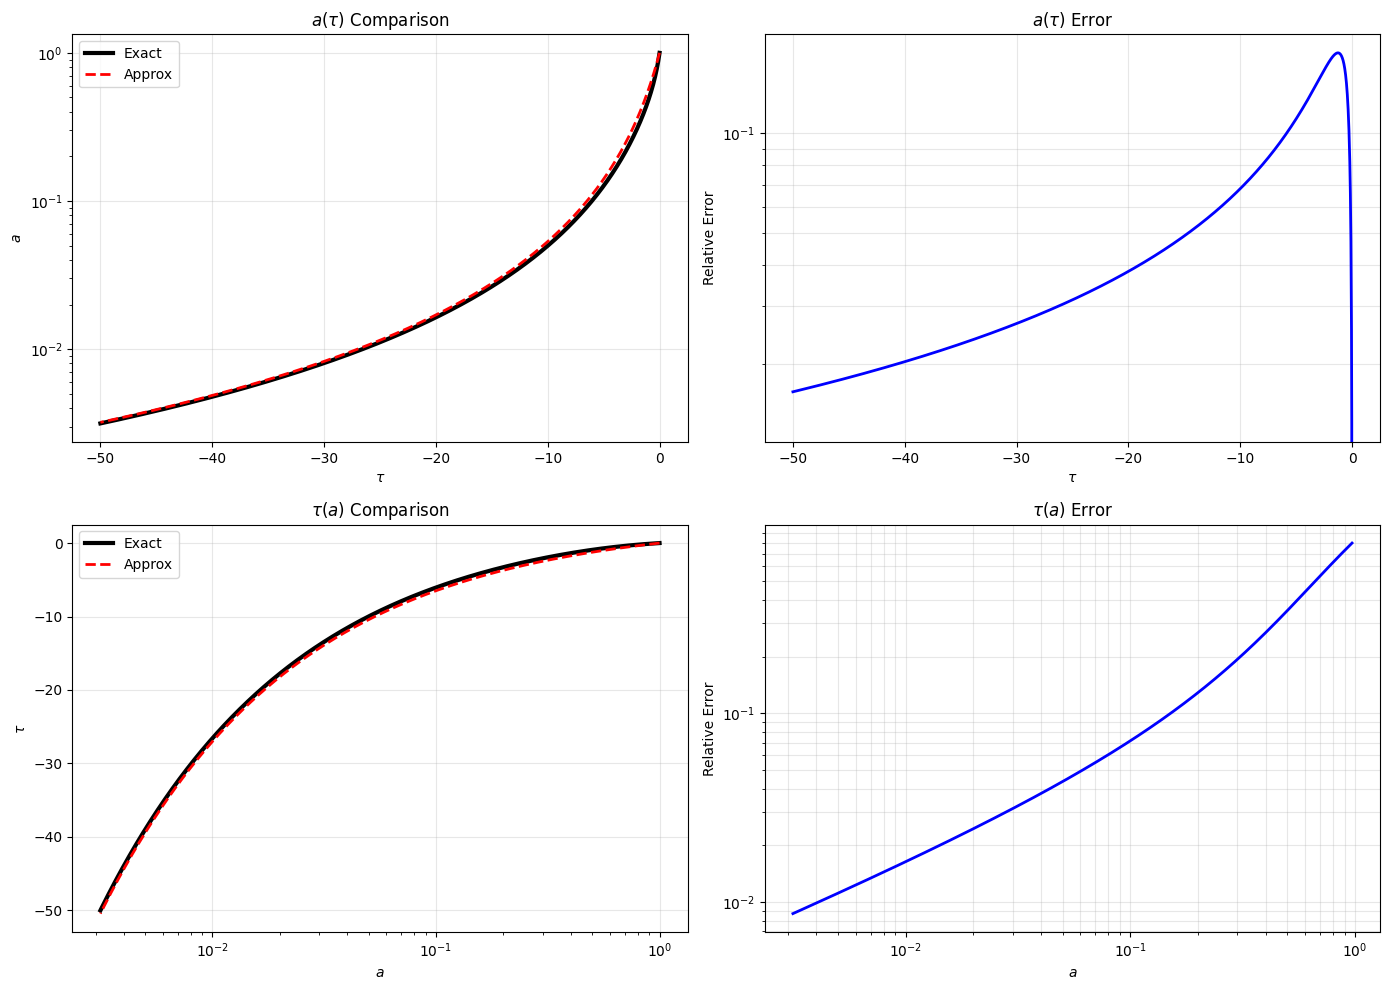

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==============================================================================
# 1. Physics Setup
# ==============================================================================
Om = 0.3
Ol = 0.7
w_de = -1.0

def get_derivatives(a, Om=Om, Ol=Ol, w=w_de):
    omHsq = 4.0 / 9.0
    a3rlm = (Ol / Om) * a**(-3 * w)
    adot  = np.sqrt(omHsq * a**3 * (1.0 + a3rlm))
    addot = a**2 * omHsq * (1.5 + 1.5 * (1.0 - w) * a3rlm)
    atdot = a * adot * omHsq * (3.0 + 1.5 * (2.0 - 3.0*w)*(1.0 - w)*a3rlm)
    return adot, addot, atdot

# ==============================================================================
# 2. Integrator (Exact solution)
# ==============================================================================
def integrate_exact(a0=1.0, tau_max=-50.0, Nsteps=2000):
    tau_arr = np.linspace(0, tau_max, Nsteps+1)
    def deriv_ivp(tau, a):
        adot,_,_ = get_derivatives(a[0])
        return [adot]
    sol = solve_ivp(deriv_ivp, [0, tau_max], [a0], t_eval=tau_arr, rtol=1e-12, atol=1e-14)
    return tau_arr, sol.y[0]

# ==============================================================================
# 3. Approximation (Matter-only tau(a))
# ==============================================================================
def tau_approx(a):
    return 3.0 * (1.0 - 1.0 / np.sqrt(a))

def a_approx(tau):
    # Inverse: a(tau) from tau = -3(1 - a^(-1/2))
    return 1.0 / (1.0 - tau/3.0)**2

# ==============================================================================
# 4. Run computation
# ==============================================================================
tau_exact, a_exact = integrate_exact()
a_app   = a_approx(tau_exact)
tau_app = tau_approx(a_exact)

# Errors
err_a   = np.abs(a_app - a_exact) / np.abs(a_exact)
err_tau = np.abs(tau_app - tau_exact) / np.abs(tau_exact)

# ==============================================================================
# 5. 2x2 PLOT
# ==============================================================================
plt.figure(figsize=(14, 10))

# -------------------- Top-left: a(tau) --------------------
plt.subplot(2, 2, 1)
plt.plot(tau_exact, a_exact, 'k-', lw=3, label='Exact')
plt.plot(tau_exact, a_app, 'r--', lw=2, label='Approx')
plt.yscale('log')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$a$')
plt.title(r'$a(\tau)$ Comparison')
plt.legend()
plt.grid(alpha=0.3)

# -------------------- Top-right: a(tau) error --------------------
plt.subplot(2, 2, 2)
plt.semilogy(tau_exact, err_a, 'b-', lw=2)
plt.xlabel(r'$\tau$')
plt.ylabel('Relative Error')
plt.title(r'$a(\tau)$ Error')
plt.grid(alpha=0.3, which='both')

# -------------------- Bottom-left: tau(a) --------------------
plt.subplot(2, 2, 3)
plt.plot(a_exact, tau_exact, 'k-', lw=3, label='Exact')
plt.plot(a_exact, tau_app, 'r--', lw=2, label='Approx')
plt.xscale('log')
plt.xlabel(r'$a$')
plt.ylabel(r'$\tau$')
plt.title(r'$\tau(a)$ Comparison')
plt.legend()
plt.grid(alpha=0.3)

# -------------------- Bottom-right: tau(a) error --------------------
plt.subplot(2, 2, 4)
plt.semilogy(a_exact, err_tau, 'b-', lw=2)
plt.xscale('log')
plt.xlabel(r'$a$')
plt.ylabel('Relative Error')
plt.title(r'$\tau(a)$ Error')
plt.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [38]:
a_exact.max()

1.0

In [37]:
tau_approx(1)

0.0

In [36]:
z_ic = 100
z_bound = 3
idx1 = np.where(a_exact == 1.0)[0][0]
idx2 = np.where(a_exact <= 1/(z_bound+1))[0][0]
idx3 = np.where(a_exact <= 1/(z_ic+1))[0][0]
print(tau_exact[idx1], tau_exact[idx2], tau_exact[idx3])
dtau_exact = tau_exact[idx1] - tau_exact[idx2]
idx_bound_exact = np.where(tau_exact < tau_exact[idx3]-dtau_exact)[0][0]
a_bound_exact = a_exact[idx_bound_exact]
print(tau_exact[idx_bound_exact],a_bound_exact,1/a_bound_exact-1)
idx1_app = np.where(a_app == 1.0)[0][0]
idx2_app = np.where(a_app <= 1/(z_bound+1))[0][0]
idx3_app = np.where(a_app <= 1/(z_ic+1))[0][0]
print(tau_app[idx1_app], tau_app[idx2_app], tau_app[idx3_app])
dtau_approx = tau_app[idx1_app] - tau_app[idx2_app]
idx_bound_approx = np.where(tau_app < tau_app[idx3_app]-dtau_approx)[0][0]
a_bound_approx = a_app[idx_bound_approx]
print(tau_app[idx_bound_approx],a_bound_approx,1/a_bound_approx-1)
err_a_approx = (a_bound_approx - a_bound_exact) / a_bound_exact
print(err_a_approx)


0.0 -2.6 -26.725
-29.35 0.008373132096947148 118.4296218454025
0.0 -3.419689897914088 -27.585156310971964
-31.0101589282785 0.007983815032747501 124.25340277777781
-0.046495989755326185


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 二阶物理响应模型
def model_second_order(x, a=2, b=3.0):
    return 1 - np.exp(-a * x) * (np.cos(b * x) + (a / b) * np.sin(b * x))

# 2. 纯有理多项式模型
# def model_Gaussian_like(x, a=3.0, b=2):
#     return 1 - np.exp(-a * x**2) + b * x**2 * np.exp(-a * x)
def model_Gaussian_like(x, a=4.0, c=2):
    b = 2*a/(2*c-2) * np.exp(c-a)
    return 1 - np.exp(-a * x**2) + b * x**2 * np.exp(-c * x**2)

# 3. 高斯修正模型
def model_gaussian_exp(x, a=4.0, c=3):
    b = 2*a/(c-2) * np.exp(c-a)
    return 1 - np.exp(-a * x**2) + b * x**2 * np.exp(-c * x)

if(1):

    # 生成数据点
    x = np.linspace(0, 10, 500)
    # 绘图配置
    plt.figure(figsize=(10, 6), dpi=120)

    y_phys = model_second_order(x)
    plt.plot(x, y_phys, label='Second-Order Response', lw=2.5)

    y_rat  = model_Gaussian_like(x)
    plt.plot(x, y_rat, label='Gaussian-like saturation', lw=2.5)

    y_gauss = model_gaussian_exp(x)
    plt.plot(x, y_gauss, label='Gaussian-Modified Exp', lw=2.5)

    # 辅助线与关键点
    plt.axhline(1, color='black', linestyle='--', alpha=0.4, label='Asymptote (y=1)')
    plt.axvline(1, color='gray', linestyle=':', alpha=0.5)
    plt.scatter([0, 1], [0, 1], color='red', zorder=5, s=50)

    # 图表格式化
    plt.title('Functions with $f(0)=0$, $f\'(0)=0$, $f(1)>1$, $f(\infty)=1$', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('f(x)', fontsize=12)
    plt.ylim(-0.1, 1.8)
    plt.xlim(-0.2, 8)
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm,LogNorm
from scipy.ndimage import gaussian_filter
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. 数据加载 ---
def loadfield2d(fn):
    with open(fn, 'rb') as fid:
        p1 = np.fromfile(fid, dtype=np.float32)
    n = int(round(len(p1) ** 0.5))
    if n**2 != len(p1): return None, 0
    return np.reshape(p1, (n, n), order='F'), n

def load2dxpos(fn):
    fid = open(fn, 'rb')
    p1 = np.fromfile(fid, dtype=np.float32)
    fid.close()
    n = round(len(p1)/2)
    if (n*2 != len(p1)):
        print('shape no mach')
        print(n,n**2,len(p1))
        return 0,0
    a = np.reshape(p1, (2, n),order='F')
    # print(fn,n)
    return a,int(np.sqrt(n))


In [ ]:
# 密度场+位移场
import numpy as np
import matplotlib.pyplot as plt

# === 参数设定 ===
ng = 3072 
downsample = 128
filename = f'{Path}3.000_dsp_H.bin'  # 文件名不带路径，确保和 Fortran 输出一致

# === 读取 Fortran 写出的 binary stream 文件 ===
with open(filename, 'rb') as f:
    dsp = np.fromfile(f, dtype=np.float32)

dsp = dsp.reshape((2, ng, ng), order='F')  # 注意 Fortran 的列优先顺序
delta,n = loadfield2d(f'{Path}3.000_delta_c.bin')
nic = n/ng

# === 网格坐标 ===
x = np.arange(ng)
y = np.arange(ng)
X, Y = np.meshgrid(x*nic, y*nic, indexing='ij')  # 和 Fortran 顺序一致

# === 位移场分量 ===
U = dsp[0, :, :]*nic  # x方向位移
V = dsp[1, :, :]*nic  # y方向位移

# === 绘图：使用 quiver 显示位移向量场 ===
plt.figure(figsize=(16,12),dpi=300)

plt.imshow(delta.T,cmap='gray')
plt.clim(-1,3)
plt.colorbar(label=r'$\delta_c$')

step = max(1, ng // downsample)  # 降采样避免箭头太密
plt.quiver(X[::step, ::step], Y[::step, ::step],
           U[::step, ::step], V[::step, ::step],
           angles='xy', scale_units='xy', scale=8, color='b',alpha=.6)

plt.title('Displacement Field')
plt.axis('equal')
plt.xlim(0, ng*nic)
plt.ylim(ng*nic, 0)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.tight_layout()
#关闭坐标轴
plt.axis('off')
plt.show()

In [ ]:
def plot_l1_l2_hist2d(l1, l2, bins=100,cm=None):
    # 1. 展平数组
    x = l1.flatten()
    y = l2.flatten()
    
    # 2. 移除异常值 (NaN/Inf)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    plt.figure(figsize=(7, 6), dpi=200)
    
    # 3. 绘制 2D 直方图
    if cm is None:
        h = plt.hist2d(x, y, bins=bins, cmap='viridis')#, norm=LogNorm())
    else:
        h = plt.hist2d(x, y, bins=bins, range=cm, cmap='viridis')#, norm=LogNorm())
    
    # 4. 辅助线：区分物理区域 (假设 l1 >= l2)
    # 理论上大部分点位于 l1=l2 线上方或下方，取决于你的排序
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    plt.plot(lims, lims, 'r--', alpha=0.5, label=r'$\lambda_1 = \lambda_2$') # 对角线
    plt.axhline(0, color='k', lw=1, alpha=0.3) # y=0
    plt.axvline(0, color='k', lw=1, alpha=0.3) # x=0

    plt.xlabel(r'$\lambda_1$')
    plt.ylabel(r'$\lambda_2$')
    plt.title(r'2D Histogram: $\lambda_1$ vs $\lambda_2$ (Log Scale)')
    plt.colorbar(label='Counts')
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

In [ ]:
Path = '/mnt/18T/output_2D/600_3072/'
l1, data_size = loadfield2d(f'{Path}3.000_G_sDsD_xf.bin')
l2, data_size = loadfield2d(f'{Path}3.000_l2_sDsD_xf.bin')
plot_l1_l2_hist2d(l1, l2,bins=1000, cm=[[-.5,1.25],[-1,1]])

In [ ]:

Path = '/mnt/18T/output_2D/600_3072/'

    
def plot_field(path, Redshift, field_name,c=None,s=None):
    if field_name == 'delta_c':
        final_title = r"$\delta_c$"
        file_redshift = Redshift
        halo_type = "xp"
        use_three_parts = False
        if c == None:
            c = (-1, 3)
        cm='gray'
        c_halo = 'r'
    elif field_name == 'delta_L':
        final_title = r"$\delta_L$"
        file_redshift = "200.000"  # 强制读取 z=200 的线性场
        halo_type = "xp"
        use_three_parts = False
        if c == None:
            c = (-1, 3)
        cm='gray'
        c_halo = 'r'
    else:
        file_redshift = Redshift
        use_three_parts = True
        if c == None:
            c = (-1, 3)
        if s == None:
            s = 0.5
        cm='bwr'
        c_halo = 'k'

    # --- 通用三段式解析逻辑 ---
    if use_three_parts:
        parts = field_name.strip('_').split('_')
        raw_a = parts[0] if len(parts) > 0 else ""
        raw_b = parts[1] if len(parts) > 1 else ""
        raw_c = parts[2] if len(parts) > 2 else ""

        # A 映射
        a_map = {'l1': r'$\lambda_1$', 'l2': r'$\lambda_2$', 'g1': r'$\gamma_1$', 
                 'g2': r'$\gamma_2$', 'E': 'Div.', 'u': r'$\mu-1$', 
                 'k': r'$\kappa$', 'j': r'$\omega$'}
        is_a_smooth = raw_a.startswith('s')
        a_key = raw_a[1:] if is_a_smooth else raw_a
        a_label = a_map.get(a_key, a_key)
        a_part = f"sm.{a_label}" if is_a_smooth else a_label

        # C 空间
        if 'q' in raw_c:
            c_part, halo_type, is_q = "Lag.", "qp", True
        else:
            is_q, halo_type = False, "xp"
            c_part = "f.Eul." if 'xf' in raw_c else "Eul."

        # B 位移场
        def get_comp(s):
            prefix = "sm." if s.startswith('s') else ""
            core = s.replace('s', '')
            symbol = r"$\Psi$" if core == 'D' else r"$\Psi_{\rm curl}$" if core == 'E'  else r"$\Psi_{\rm halo}$" if core == 'H' else core
            return f"{prefix}{symbol}"

        b_tokens = []
        temp_b = raw_b
        for pattern in ['sD', 'sE', 'D', 'E', 'H','sH']: # 简化的token识别
            while pattern in temp_b:
                b_tokens.append(pattern)
                temp_b = temp_b.replace(pattern, '', 1)

        if len(b_tokens) >= 2 and not is_q:
            b_part = f"gen.{get_comp(b_tokens[0])}/shft.{get_comp(b_tokens[1])}"
        else:
            token = b_tokens[0] if b_tokens else raw_b
            b_part = f"gen.{get_comp(token)}"

        final_title = f"{a_part} | {b_part} ({c_part})"
    else:
        # 特殊情况下的 a_key 处理，防止后续 u 的逻辑报错
        a_key = field_name 

    # 3. 加载数据
    delta, ng = loadfield2d(f'{path}{file_redshift}_{field_name}.bin')
    if a_key == 'u':
        delta = delta - 1

    # 根据 C 的判断加载对应的 halo
    halo,nh = load2dxpos(f'{path}{file_redshift}_halo_{halo_type}_mean_only.bin')

    # if ng != nh:
    #     print(f"Warning: ng ({ng}) != nh ({nh})")
    #     return

    # 4. 绘图
    plt.figure(figsize=(6, 5), dpi=200)
    plt.imshow(delta.T, interpolation='none', cmap=cm)
    plt.clim(c[0], c[1])
    plt.colorbar()
    # 画出 halo
    plt.scatter(halo[0, :], halo[1, :], s=s, c=c_halo, alpha=0.1)

    # 限制坐标轴范围
    plt.xlim(0, ng)
    plt.ylim(0, ng)
    plt.xlabel(r'Grid $x$')
    plt.ylabel(r'Grid $y$')
    plt.title(final_title)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_field(Path, '3.000', 'E_HH_xf',[-.5,.5],s=0)

In [ ]:
plot_field(Path, '3.000', 'E_sDsD_xf',[-.5,.5],s=0)

In [ ]:
plot_field(Path, '3.000', 'l2_sDsD_xf',[-.5,.5])

In [ ]:
plot_field(Path, '3.000', 'l1_sDsD_xf',[-.5,.5])

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import gaussian_filter
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. 数据加载 ---
def loadfield2d(fn):
    with open(fn, 'rb') as fid:
        p1 = np.fromfile(fid, dtype=np.float32)
    n = int(round(len(p1) ** 0.5))
    if n**2 != len(p1): return None, 0
    return np.reshape(p1, (n, n), order='F'), n

# --- 加载数据 ---
Path = '/mnt/18T/output_2D/600_3072/'
delta_DE, data_size = loadfield2d(f'{Path}3.000_l1D_q.bin')

plt.figure(figsize=(6,5),dpi=200)
plt.imshow(delta_DE.T, interpolation='none',cmap='bwr')
plt.title('delta_cE')
plt.clim(-1,1)
plt.colorbar()
# plt.title(f'delta_cE simgaussian_filter({g})')
plt.show()

In [ ]:
%matplotlib inline


# --- 加载数据 ---
delta_DE, data_size = loadfield2d(f'{Path}3.000_E_sDsD_x.bin')

plt.figure(figsize=(6,5),dpi=200)
plt.imshow(delta_DE.T, interpolation='none',cmap='bwr')
plt.title('E_sD_x')
plt.clim(-1,1)
plt.colorbar()
# plt.title(f'delta_cE simgaussian_filter({g})')
plt.show()

In [ ]:

A_sD_x, data_size = loadfield2d(f'{Path}3.000_delta_c.bin')

plt.figure(figsize=(6,5),dpi=200)
plt.imshow(A_sD_x.T, interpolation='none',cmap='gray')
plt.title('delta_c')
plt.clim(-1,3)
plt.colorbar()
plt.show()

In [ ]:

A_sD_x, data_size = loadfield2d(f'{Path}3.000_u_sD_q.bin')

plt.figure(figsize=(6,5),dpi=200)
plt.imshow(A_sD_x.T-1, interpolation='none',cmap='bwr')
plt.title('u_sD_q-1')
plt.clim(-1,1)
plt.colorbar()
plt.show()

In [ ]:

A_sD_x, data_size = loadfield2d(f'{Path}3.000_u_D_q_s.bin')

plt.figure(figsize=(6,5),dpi=200)
plt.imshow(A_sD_x.T-1, interpolation='none',cmap='bwr')
plt.title('su_D_q-1')
plt.clim(-1,1)
plt.colorbar()
plt.show()

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import gaussian_filter
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. 数据加载 ---
def loadfield2d(fn):
    with open(fn, 'rb') as fid:
        p1 = np.fromfile(fid, dtype=np.float32)
    n = int(round(len(p1) ** 0.5))
    if n**2 != len(p1): return None, 0
    return np.reshape(p1, (n, n), order='F'), n

# --- 加载数据 ---
Path = '/mnt/18T/output_2D/600_3072/'
l1, data_size = loadfield2d(f'{Path}3.000_l1_sDsD_xf.bin')
l2, data_size = loadfield2d(f'{Path}3.000_l2_sDsD_xf.bin')
# 清理l1,l2的异常值(nan inf)
# l1 = np.nan_to_num(l1, nan=0.0, posinf=0.0, neginf=0.0)
# l2 = np.nan_to_num(l2, nan=0.0, posinf=0.0, neginf=0.0)
# plt.figure(figsize=(6,5),dpi=200)
# plt.imshow(l1.T, interpolation='none',cmap='bwr')
# plt.title('l1_sD_x')
# plt.clim(-.3,.3)
# plt.colorbar()
# plt.show()
# plt.figure(figsize=(6,5),dpi=200)
# plt.imshow(l2.T, interpolation='none',cmap='bwr')
# plt.title('l2_sD_x')
# plt.clim(-3,3)
# plt.colorbar()
# plt.show()
# plt.figure(figsize=(6,5),dpi=200)
# plt.imshow(np.sqrt(l1**2+l2**2).T, interpolation='none',cmap='bwr')
# plt.title('g_sD_q')
# plt.clim(-3,3)
# plt.colorbar()
# plt.show()


# l1 = gaussian_filter(l1, sigma=5)
# l2 = gaussian_filter(l2, sigma=5)

# plt.figure(figsize=(6,5),dpi=200)
# plt.imshow(l1.T, interpolation='none',cmap='bwr')
# plt.title('sl1_D_q')
# plt.clim(-1,1)
# plt.colorbar()
# plt.show()
# plt.figure(figsize=(6,5),dpi=200)
# plt.imshow(l2.T, interpolation='none',cmap='bwr')
# plt.title('sl2_D_q')
# plt.clim(-1,1)
# plt.colorbar()
# plt.show()
# delta_DE = np.sqrt(-(l1*l2))

halo,nh = load2dxpos(f'{Path}{'3.000'}_halo_{'xp'}_mean_only.bin')

# plt.figure(figsize=(6,5),dpi=200)
# plt.imshow(delta_DE.T, interpolation='none',cmap='Blues')
# plt.title('A')
# plt.xlim(0, data_size)
# plt.ylim(0, data_size)
# plt.xlabel(r'Grid $x$')
# plt.ylabel(r'Grid $y$')
# plt.clim(0,.6)
# plt.colorbar()
# plt.scatter(halo[0, :], halo[1, :], s=0.5, c='k', alpha=0.1)
# plt.show()

In [ ]:
# delta_DE, data_size = loadfield2d(f'{Path}3.000_k_sDsD_xf.bin')
plt.figure(figsize=(6,5),dpi=1000)
plt.imshow(-delta_DE.T, interpolation='none',cmap='bwr')
plt.title(r'$\kappa$')
plt.xlim(0, data_size)
plt.ylim(0, data_size)
plt.xlabel(r'Grid $x$')
plt.ylabel(r'Grid $y$')
plt.clim(-.5,.5)
plt.colorbar()
plt.scatter(halo[0, :], halo[1, :], s=0.5, c='k')
plt.show()

In [ ]:

plt.figure(figsize=(6,5),dpi=1000)
plt.show()

In [ ]:

Path = '/mnt/18T/output_2D/600_3072/'
l1, data_size = loadfield2d(f'{Path}3.000_l1_sDsD_xf.bin')
l2, data_size = loadfield2d(f'{Path}3.000_l2_sDsD_xf.bin')
delta_DE = (l1+l2)/2
# delta_DE = np.zeros(delta_DE.shape)

# halo,nh = load2dxpos(f'{Path}{'3.000'}_halo_{'xp'}_mean_only.bin')

plt.figure(figsize=(6,5),dpi=1000)
plt.imshow(delta_DE.T, interpolation='none',cmap='bwr')
plt.title(r'$\mu$')
plt.xlim(0, data_size)
plt.ylim(0, data_size)
plt.xlabel(r'Grid $x$')
plt.ylabel(r'Grid $y$')
# plt.clim(-.5,.5)
plt.colorbar()
plt.scatter(halo[0, :], halo[1, :], s=0.5, c='k')
plt.show()

In [ ]:

Path = '/mnt/18T/output_2D/600_3072/'
l2, data_size = loadfield2d(f'{Path}3.000_l2_sDsD_xf.bin')
mu, data_size = loadfield2d(f'{Path}3.000_u_sDsD_xf.bin')

mu = mu -1
mu[ l2 >= 0 ] = np.nan

# halo,nh = load2dxpos(f'{Path}{'3.000'}_halo_{'xp'}_mean_only.bin')

plt.figure(figsize=(6,5),dpi=300)
plt.imshow(mu.T, interpolation='none',cmap='bwr')
plt.title(r'$\mu$')
plt.xlim(0, data_size)
plt.ylim(0, data_size)
plt.xlabel(r'Grid $x$')
plt.ylabel(r'Grid $y$')
plt.clim(-.5,.5)
plt.colorbar()
plt.scatter(halo[0, :], halo[1, :], s=0.5, c='k')
plt.show()

In [ ]:

Path = '/mnt/18T/output_2D/600_3072/'
l2, data_size = loadfield2d(f'{Path}3.000_l2_sDsD_xf.bin')
mu, data_size = loadfield2d(f'{Path}3.000_E_sDsD_xf.bin')

mu[ l2 >= 0 ] = np.nan

# halo,nh = load2dxpos(f'{Path}{'3.000'}_halo_{'xp'}_mean_only.bin')

plt.figure(figsize=(6,5),dpi=300)
plt.imshow(mu.T, interpolation='none',cmap='bwr')
plt.title(r'$Div.$')
plt.xlim(0, data_size)
plt.ylim(0, data_size)
plt.xlabel(r'Grid $x$')
plt.ylabel(r'Grid $y$')
plt.clim(-.5,.5)
plt.colorbar()
plt.scatter(halo[0, :], halo[1, :], s=0.5, c='k')
plt.show()

In [ ]:
delta_DE = (-(l1*l2))**(1/4)

halo,nh = load2dxpos(f'{Path}{'3.000'}_halo_{'xp'}_mean_only.bin')

plt.figure(figsize=(6,5),dpi=1000)
plt.imshow(delta_DE.T, interpolation='none',cmap='Blues')
plt.title('A')
plt.xlim(0, data_size)
plt.ylim(0, data_size)
plt.xlabel(r'Grid $x$')
plt.ylabel(r'Grid $y$')
plt.clim(0,.6)
plt.colorbar()
plt.scatter(halo[0, :], halo[1, :], s=0.5, c='r')
plt.show()

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import gaussian_filter
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. 数据加载 ---
def loadfield2d(fn):
    with open(fn, 'rb') as fid:
        p1 = np.fromfile(fid, dtype=np.float32)
    n = int(round(len(p1) ** 0.5))
    if n**2 != len(p1): return None, 0
    return np.reshape(p1, (n, n), order='F'), n

# --- 加载数据 ---
Path = '/mnt/18T/output_2D/600_3072/'
delta_DE, data_size = loadfield2d(f'{Path}3.000_E_q.bin')
delta_DE, data_size = loadfield2d(f'{Path}3.000_delta_cE.bin')

# --- 2. 预计算缓存 ---
cache = {}

# --- 3. 创建输出容器 ---
plot_out = widgets.Output()

# --- 4. 创建竖向滑块 (三列独立控制) ---
slider_layout = widgets.Layout(height='450px', width='80px', align_items='center')

gss_slider = widgets.FloatSlider(
    min=0.5, max=5.0, step=0.1, value=1.0, 
    description='Sigma', orientation='vertical', 
    continuous_update=False, layout=slider_layout
)

# --- 5. 绘图逻辑 ---
def update_plot(change=None):
    g= gss_slider.value
    
    if g not in cache:
        cache[g] = gaussian_filter(delta_DE, sigma=g)
    smoothed = cache[g]
    
    with plot_out:
        clear_output(wait=True)
        plt.figure(figsize=(6,5),dpi=200)
        plt.imshow(smoothed.T, interpolation='none',cmap='bwr')
        plt.title('delta_cE')
        plt.clim(-1,1)
        plt.colorbar()
        # plt.title(f'delta_cE simgaussian_filter({g})')
        plt.show()

# 绑定观察者
for s in [gss_slider, fd_slider, fu_slider]:
    s.observe(update_plot, names='value')

# --- 6. 布局设计 (关键部分) ---
# 将每个滑块和它的标题组成一个小竖列
col1 = widgets.VBox([ gss_slider])

# 将三列滑块并排
controls_hbox = widgets.HBox([col1], layout=widgets.Layout(margin='0 30px'))

# 最终布局：[ 图像 | 三列滑块 ]
final_ui = widgets.HBox([plot_out, controls_hbox], layout=widgets.Layout(align_items='center'))

display(final_ui)
update_plot()

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import gaussian_filter
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. 数据加载 ---
def loadfield2d(fn):
    with open(fn, 'rb') as fid:
        p1 = np.fromfile(fid, dtype=np.float32)
    n = int(round(len(p1) ** 0.5))
    if n**2 != len(p1): return None, 0
    return np.reshape(p1, (n, n), order='F'), n

# --- 加载数据 ---
Path = '/mnt/18T/output_2D/600_3072/'
delta_DE, data_size = loadfield2d(f'{Path}3.000_EE_xf.bin')

# --- 2. 预计算缓存 ---
cache = {}

# --- 3. 创建输出容器 ---
plot_out = widgets.Output()

# --- 4. 创建竖向滑块 (三列独立控制) ---
slider_layout = widgets.Layout(height='450px', width='80px', align_items='center')

gss_slider = widgets.FloatSlider(
    min=0.5, max=5.0, step=0.1, value=1.0, 
    description='Sigma', orientation='vertical', 
    continuous_update=False, layout=slider_layout
)

fd_slider = widgets.FloatSlider(
    min=-2, max=1.0, step=0.05, value=0.0, 
    description='fd (Void)', orientation='vertical', 
    continuous_update=False, layout=slider_layout
)

fu_slider = widgets.FloatSlider(
    min=0, max=2.0, step=0.05, value=2.0, 
    description='fu (Node)', orientation='vertical', 
    continuous_update=False, layout=slider_layout
)

# --- 5. 绘图逻辑 ---
def update_plot(change=None):
    g, d, u = gss_slider.value, fd_slider.value, fu_slider.value
    
    if g not in cache:
        cache[g] = gaussian_filter(delta_DE, sigma=g)
    smoothed = cache[g]
    
    mask = np.full_like(smoothed, 1.5)
    mask[smoothed < d] = 0.5
    mask[smoothed > u] = 2.5
    
    with plot_out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 8))
        cmap = ListedColormap(['blue', 'white', 'red'])
        norm = BoundaryNorm([0, 1, 2, 3], cmap.N)
        
        # 针对 3072 数据量，必须下采样显示 (1/4 像素) 否则 VS Code 远程会断连
        step = 4 
        im = ax.imshow(mask[::step, ::step].T, cmap=cmap, norm=norm, origin='lower', interpolation='none')
        
        ax.set_ylim(data_size//step, 0)
        ax.set_title(f'Sigma: {g} | fd: {d:.1f} | fu: {u:.1f}')
        
        cbar = fig.colorbar(im, ticks=[0.5, 1.5, 2.5], fraction=0.046, pad=0.04)
        cbar.ax.set_yticklabels(['void', 'filament', 'node'])
        plt.show()

# 绑定观察者
for s in [gss_slider, fd_slider, fu_slider]:
    s.observe(update_plot, names='value')

# --- 6. 布局设计 (关键部分) ---
# 将每个滑块和它的标题组成一个小竖列
col1 = widgets.VBox([ gss_slider])
col2 = widgets.VBox([fd_slider])
col3 = widgets.VBox([fu_slider])

# 将三列滑块并排
controls_hbox = widgets.HBox([col1, col2, col3], layout=widgets.Layout(margin='0 0 0 30px'))

# 最终布局：[ 图像 | 三列滑块 ]
final_ui = widgets.HBox([plot_out, controls_hbox], layout=widgets.Layout(align_items='center'))

display(final_ui)
update_plot()